In [ ]:
!pip install geopandas

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving geo_health_access.csv to geo_health_access (1).csv


In [ ]:
geo = pd.read_csv('geo_health_access.csv')
geo.head()

,zip_code,county,population,number_of_clinics,avg_distance_to_clinic_km,healthcare_desert_flag
0,75000,Collin,6,4,23.98,No
1,75000,Dallas,6,2,11.53,No
2,75000,Denton,11,6,16.60,No
3,75000,Harris,15,3,15.93,No
4,75000,Tarrant,11,9,2.45,No


In [23]:
uploaded = files.upload()

Saving tl_2025_us_zcta520.zip to tl_2025_us_zcta520.zip


In [32]:
import zipfile
import os

with zipfile.ZipFile("tl_2025_us_zcta520.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [33]:
import geopandas as gpd

# The path to the .shp file within your 'data' folder
file_path = "data/tl_2025_us_zcta520.shp"

# Load the data into a GeoDataFrame
gdf = gpd.read_file(file_path)

# View the first few rows
print(gdf.head())

# Check the coordinate reference system (usually EPSG:4269 for Census data)
print(gdf.crs)

  ZCTA5CE20 GEOID20       GEOIDFQ20 CLASSFP20 MTFCC20 FUNCSTAT20    ALAND20  \
0     81137   81137  860Z200US81137        B5   G6350          S  668834096   
1     80823   80823  860Z200US80823        B5   G6350          S  731738462   
2     81237   81237  860Z200US81237        B5   G6350          S  139553440   
3     81251   81251  860Z200US81251        B5   G6350          S  360441690   
4     81435   81435  860Z200US81435        B5   G6350          S  494557780   

   AWATER20   INTPTLAT20    INTPTLON20  \
0  16883364  +37.0519107  -107.6136014   
1   2846899  +38.6634637  -103.4191862   
2     99778  +38.6163123  -106.6212538   
3   9653596  +39.1425479  -106.4375793   
4   1109655  +37.8687513  -107.9251168   

                                            geometry  
0  POLYGON ((-107.85404 37.08409, -107.85403 37.0...  
1  POLYGON ((-103.70667 38.68072, -103.70602 38.6...  
2  POLYGON ((-106.6865 38.57901, -106.68645 38.57...  
3  POLYGON ((-106.58611 39.09058, -106.58616 39.0...

In [43]:
file_path = "data/tl_2025_us_zcta520.shp"

zip_shapes = gpd.read_file(file_path)
zip_shapes.head()

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
0,81137,81137,860Z200US81137,B5,G6350,S,668834096,16883364,+37.0519107,-107.6136014,"POLYGON ((-107.85404 37.08409, -107.85403 37.0..."
1,80823,80823,860Z200US80823,B5,G6350,S,731738462,2846899,+38.6634637,-103.4191862,"POLYGON ((-103.70667 38.68072, -103.70602 38.6..."
2,81237,81237,860Z200US81237,B5,G6350,S,139553440,99778,+38.6163123,-106.6212538,"POLYGON ((-106.6865 38.57901, -106.68645 38.57..."
3,81251,81251,860Z200US81251,B5,G6350,S,360441690,9653596,+39.1425479,-106.4375793,"POLYGON ((-106.58611 39.09058, -106.58616 39.0..."
4,81435,81435,860Z200US81435,B5,G6350,S,494557780,1109655,+37.8687513,-107.9251168,"POLYGON ((-108.19918 37.82435, -108.19915 37.8..."


In [44]:
# Ensure ZIP codes are strings and 5 digits
geo['zip_code'] = geo['zip_code'].astype(str).str.zfill(5)

# Check shapefile column name
zip_shapes.columns

Index(['ZCTA5CE20', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'geometry'],
      dtype='object')

In [45]:
zip_shapes['ZCTA5CE20'] = zip_shapes['ZCTA5CE20'].astype(str).str.zfill(5)

In [46]:
merged = zip_shapes.merge(
    geo,
    left_on='ZCTA5CE20',
    right_on='zip_code',
    how='inner'
)

merged.head()

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry,zip_code,county,population,number_of_clinics,avg_distance_to_clinic_km,healthcare_desert_flag
0,75428,75428,860Z200US75428,B5,G6350,S,240548061,982278,+33.2747039,-095.9175612,"POLYGON ((-96.04432 33.26706, -96.0443 33.2671...",75428,Collin,9,8,4.21,No
1,75428,75428,860Z200US75428,B5,G6350,S,240548061,982278,+33.2747039,-095.9175612,"POLYGON ((-96.04432 33.26706, -96.0443 33.2671...",75428,Dallas,7,6,19.92,No
2,75428,75428,860Z200US75428,B5,G6350,S,240548061,982278,+33.2747039,-095.9175612,"POLYGON ((-96.04432 33.26706, -96.0443 33.2671...",75428,Denton,6,5,14.12,No
3,75428,75428,860Z200US75428,B5,G6350,S,240548061,982278,+33.2747039,-095.9175612,"POLYGON ((-96.04432 33.26706, -96.0443 33.2671...",75428,Harris,9,5,2.28,No
4,75428,75428,860Z200US75428,B5,G6350,S,240548061,982278,+33.2747039,-095.9175612,"POLYGON ((-96.04432 33.26706, -96.0443 33.2671...",75428,Tarrant,8,7,10.87,No


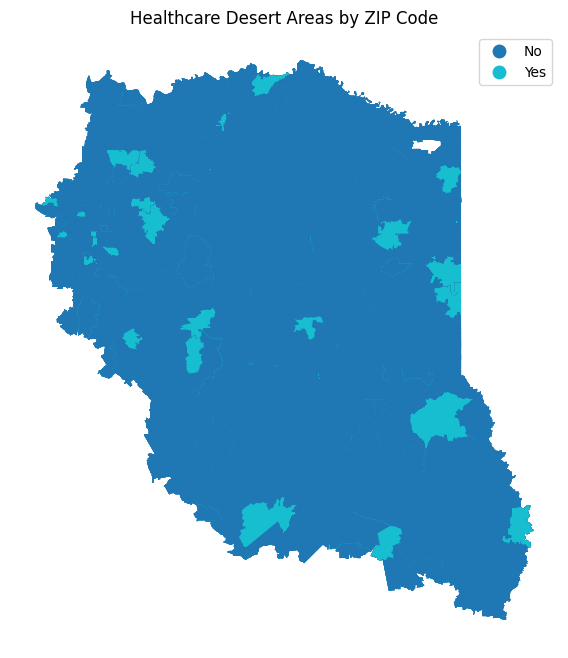

In [47]:
fig, ax = plt.subplots(figsize=(12, 8))

merged.plot(
    column='healthcare_desert_flag',
    legend=True,
    ax=ax
)

plt.title("Healthcare Desert Areas by ZIP Code")
plt.axis('off')
plt.show()

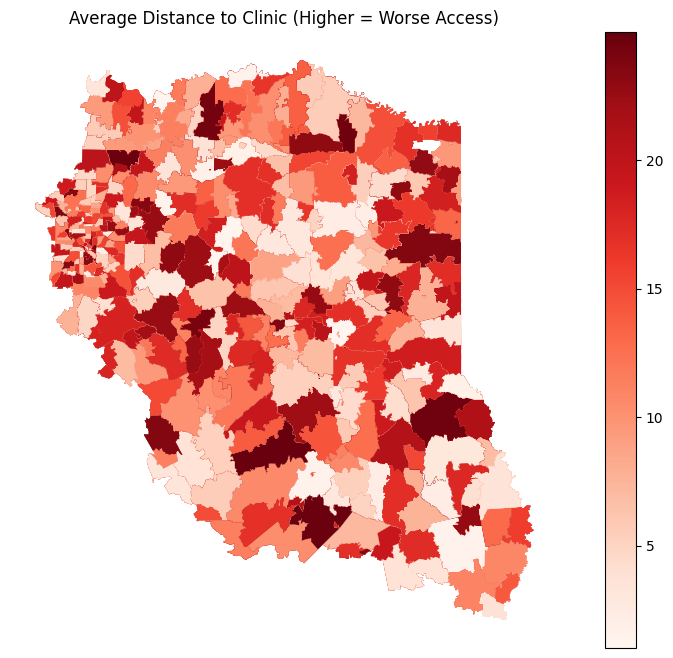

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

merged.plot(
    column='avg_distance_to_clinic_km',
    cmap='Reds',
    legend=True,
    ax=ax
)

plt.title("Average Distance to Clinic (Higher = Worse Access)")
plt.axis('off')
plt.show()

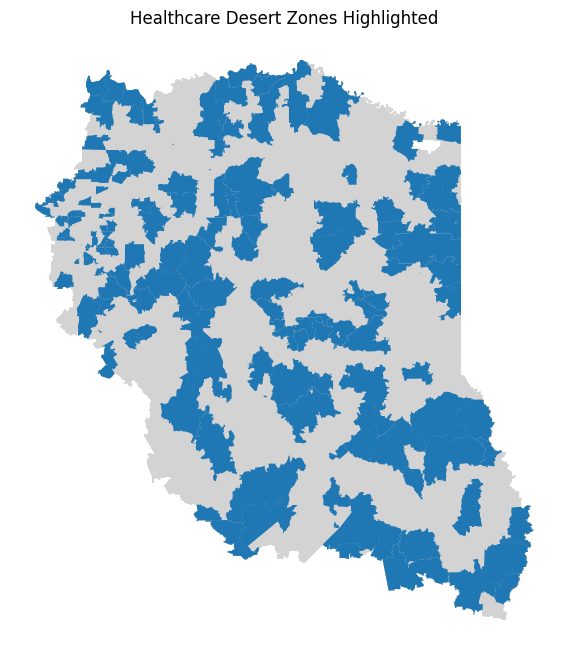

In [49]:
deserts = merged[merged['healthcare_desert_flag'] == 'Yes']

base = merged.plot(color='lightgrey', figsize=(12,8))
deserts.plot(ax=base)

plt.title("Healthcare Desert Zones Highlighted")
plt.axis('off')
plt.show()

In [50]:
top_deserts = deserts.sort_values(
    by='avg_distance_to_clinic_km',
    ascending=False
)[['zip_code', 'county', 'population', 'avg_distance_to_clinic_km']].head(10)

top_deserts

,zip_code,county,population,avg_distance_to_clinic_km
1736,75782,Tarrant,5,24.86
2181,75409,Travis,4,24.77
833,75780,Travis,8,24.72
1109,75935,Travis,12,24.60
568,75931,Tarrant,9,24.52
1093,75656,Dallas,10,24.48
1574,75411,Harris,7,24.42
1816,75202,Collin,8,24.42
432,75214,Collin,9,24.29
2039,75436,Dallas,5,24.26


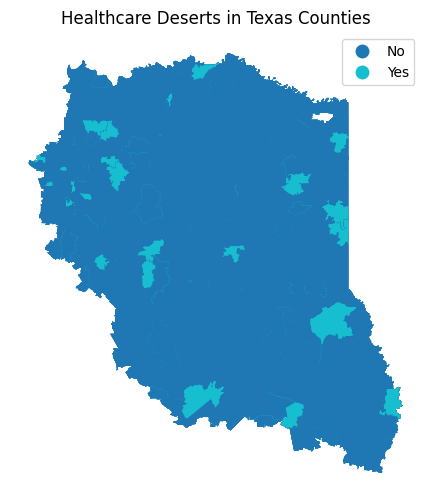

In [51]:
tx = merged[merged['county'].isin(['Dallas','Collin','Denton','Tarrant','Travis','Harris'])]

fig, ax = plt.subplots(figsize=(10, 6))
tx.plot(
    column='healthcare_desert_flag',
    legend=True,
    ax=ax
)

plt.title("Healthcare Deserts in Texas Counties")
plt.axis('off')
plt.show()